# Test SVS → GigaTIME Tiles Preprocessing Pipeline

This notebook runs the preprocessing pipeline on SVS slides under `data/svs data/`, writes tiles in the same layout as sample_test_data, and verifies that the output can be fed into the GigaTIME model (generate_tile_pair_df + dataloader).

In [1]:
import sys
from pathlib import Path

ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path(".").resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import yaml
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from preprocessing.run import process_slide, process_slides, load_config, write_metadata_csv
from preprocessing.wsi import open_slide, get_thumbnail

Paths and config

In [2]:
input_dir = ROOT / "data" / "svs data"
output_dir = ROOT / "data" / "preprocessed_tiles"
config = load_config(ROOT / "preprocessing" / "config.yaml")
print("Input:", input_dir)
print("Output:", output_dir)
print("Config:", config)

Input: C:\Users\xdpik\Documents\NYU\Spring 2026\GigaTIME\data\svs data
Output: C:\Users\xdpik\Documents\NYU\Spring 2026\GigaTIME\data\preprocessed_tiles
Config: {'tile_size': 556, 'magnification': 20, 'stride': 556, 'tissue_threshold': 0.8, 'min_variance': 200, 'normalize_stain': False, 'output_format': 'png', 'num_comet_channels': 23}


Discover SVS files

In [3]:
svs_list = sorted(input_dir.rglob("*.svs"))
print(f"Found {len(svs_list)} SVS file(s):")
for p in svs_list:
    print(" ", p)

Found 3 SVS file(s):
  C:\Users\xdpik\Documents\NYU\Spring 2026\GigaTIME\data\svs data\33635671-d513-4781-bb19-982ee75ac21b\TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297-d068d80107c7.svs
  C:\Users\xdpik\Documents\NYU\Spring 2026\GigaTIME\data\svs data\344626d3-c3ea-4bb6-9ba5-5f54dc5c2b01\TCGA-IB-7647-01Z-00-DX1.9ECB677F-8B28-424B-81FC-0D0AD1E25865.svs
  C:\Users\xdpik\Documents\NYU\Spring 2026\GigaTIME\data\svs data\e5c7da8a-42f6-4211-bfc4-5abb1a50dff6\TCGA-IB-7647-01A-01-TS1.60574eeb-7935-4607-9ca8-5e1c21684ea5.svs


Run pipeline (first slide or all)

In [4]:
# Process first slide only for a quick test; set to False to process all
first_slide_only = True

if first_slide_only and svs_list:
    svs_path = svs_list[0]
    num_tiles, slide_dir = process_slide(svs_path, output_dir, config)
    print(f"Wrote {num_tiles} tiles to {slide_dir}")
    write_metadata_csv(output_dir, [svs_path.stem])
else:
    results = process_slides(input_dir, output_dir, config, write_metadata=True)
    for slide_id, n, slide_dir in results:
        print(f"{slide_id}: {n} tiles -> {slide_dir}")

Wrote 278 tiles to C:\Users\xdpik\Documents\NYU\Spring 2026\GigaTIME\data\preprocessed_tiles\TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297-d068d80107c7_and_TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297-d068d80107c7


Sanity checks: list tiles and display sample

TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297-d068d80107c7_and_TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297-d068d80107c7: 278 tiles
TCGA-IB-7647-01Z-00-DX1.9ECB677F-8B28-424B-81FC-0D0AD1E25865_and_TCGA-IB-7647-01Z-00-DX1.9ECB677F-8B28-424B-81FC-0D0AD1E25865: 124 tiles


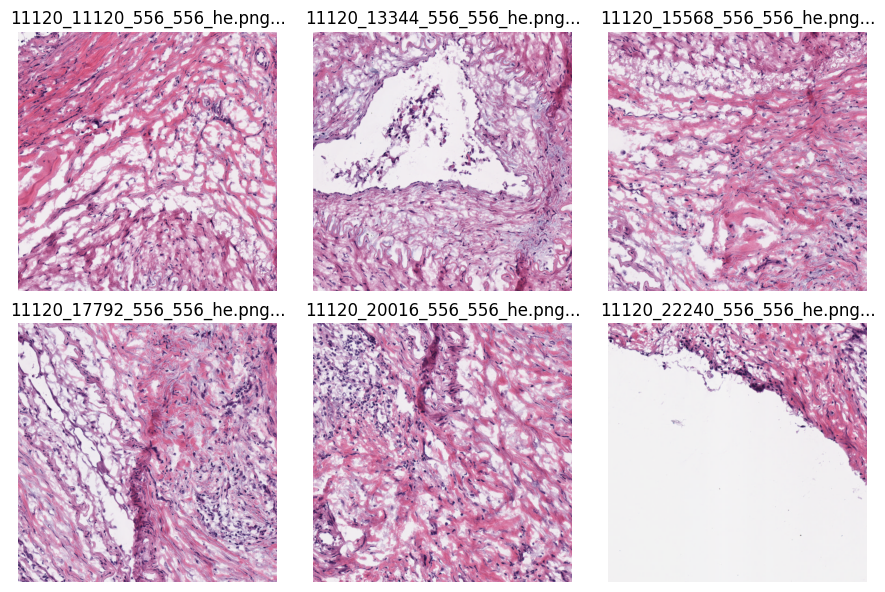

In [5]:
slide_dirs = [d for d in output_dir.iterdir() if d.is_dir() and "_and_" in d.name]
if not slide_dirs:
    print("No slide dirs found. Run the pipeline cell first.")
else:
    for d in slide_dirs:
        he_files = sorted(d.glob("*_he.png"))
        print(f"{d.name}: {len(he_files)} tiles")
    # Display a 2x3 grid of tiles from first slide
    d = slide_dirs[0]
    he_files = sorted(d.glob("*_he.png"))[:6]
    fig, axes = plt.subplots(2, 3, figsize=(9, 6))
    for ax, fp in zip(axes.flat, he_files):
        ax.imshow(Image.open(fp).convert("RGB"))
        ax.set_title(fp.name[:30] + "...")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

Model compatibility check: load preprocessed output with generate_tile_pair_df and dataloader

In [6]:
import os
scripts_dir = ROOT / "scripts"
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))
import pandas as pd
import torch
from pathlib import Path as P

from prov_data import generate_tile_pair_df, get_image_roi, unpack_and_load, HECOMETDataset_roi
from albumentations import geometric
from albumentations.augmentations import transforms
from albumentations.core.composition import Compose

metadata_path = output_dir / "preprocessed_metadata.csv"
if not metadata_path.exists():
    print("Run pipeline first so preprocessed_metadata.csv exists.")
else:
    metadata = pd.read_csv(metadata_path)
    tiling_dir = P(output_dir)
    tile_pair_df = generate_tile_pair_df(metadata=metadata, tiling_dir=tiling_dir)
    print("Tile pair df shape:", tile_pair_df.shape)
    print(tile_pair_df.head())

    # Build dataset and load one batch
    val_transform = Compose([
        geometric.Resize(512, 512),
        transforms.Normalize(),
    ])
    dataset = HECOMETDataset_roi(
        all_tile_pair=tile_pair_df,
        tile_pair_df=tile_pair_df,
        transform=val_transform,
        dir_path=str(tiling_dir),
        window_size=512,
        split="full",
        standard="all",
        mask_noncell=True,
        cell_mask_label=True,
    )
    if len(dataset) > 0:
        img, mask, meta = dataset[0]
        print(f"Batch 0: img shape {img.shape}, mask shape {mask.shape}")
        print("Model compatibility OK: preprocessed tiles load like sample_test_data.")
    else:
        print("No tiles in dataset.")

Tile pair df shape: (278, 15)
                                                   img_comet_black_ratio  \
TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297...                   0.0   
TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297...                   0.0   
TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297...                   0.0   
TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297...                   0.0   
TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297...                   0.0   

                                                   img_comet_variance  \
TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297...              255.0   
TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297...              255.0   
TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297...              255.0   
TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297...              255.0   
TCGA-IB-7647-01A-01-BS1.01002327-bb52-4efd-8297...              255.0   

                                                   img_he_black_ratio  \
T

c:\Users\xdpik\miniconda3\envs\gigatime_check_1\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
C:\Users\xdpik\Documents\NYU\Spring 2026\GigaTIME\scripts\prov_data.py:266: FutureWarning: `RegionProperties.convex_image` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.image_convex` instead. 
  region_mask = region.convex_image # Shape: (region_height, region_width)


Run GigaTIME model on preprocessed tiles

Load the pretrained GigaTIME model from HuggingFace and run inference on a few batches of preprocessed tiles. Requires the compatibility cell above to have been run (so `dataset` and `tiling_dir` exist), or preprocessed output to exist.

In [7]:
# Run GigaTIME model on preprocessed tiles
import os
scripts_dir = ROOT / "scripts"
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

import torch
import pandas as pd
from pathlib import Path as P
from albumentations import geometric
from albumentations.augmentations import transforms
from albumentations.core.composition import Compose

import archs
import losses
from prov_data import generate_tile_pair_df, HECOMETDataset_roi

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Rebuild dataset if not in scope (e.g. if this cell is run alone)
metadata_path = output_dir / "preprocessed_metadata.csv"
try:
    _has_dataset = dataset is not None and len(dataset) > 0
except NameError:
    _has_dataset = False
if metadata_path.exists() and not _has_dataset:
    metadata = pd.read_csv(metadata_path)
    tiling_dir = P(output_dir).resolve()
    tile_pair_df = generate_tile_pair_df(metadata=metadata, tiling_dir=tiling_dir)
    val_transform = Compose([geometric.Resize(512, 512), transforms.Normalize()])
    dataset = HECOMETDataset_roi(
        all_tile_pair=tile_pair_df, tile_pair_df=tile_pair_df,
        transform=val_transform, dir_path=str(tiling_dir), window_size=512,
        split="full", standard="all", mask_noncell=True, cell_mask_label=True,
    )
    print("Built dataset:", len(dataset), "tiles")
elif not metadata_path.exists():
    dataset = []

if not (hasattr(dataset, "__len__") and len(dataset) > 0):
    print("No preprocessed tiles. Run the pipeline and compatibility cells first.")
else:
    # Model config (match gigatime_testing)
    model_config = {"arch": "gigatime", "num_classes": 23, "input_channels": 3}
    model = archs.__dict__[model_config["arch"]](model_config["num_classes"], model_config["input_channels"])

    try:
        from huggingface_hub import snapshot_download
    except ModuleNotFoundError:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "huggingface_hub"])
        from huggingface_hub import snapshot_download

    repo_id = "prov-gigatime/GigaTIME"
    local_dir = snapshot_download(repo_id=repo_id, token=os.environ.get("HF_TOKEN"))
    # Compatibility: HuggingFace checkpoint was saved with older PyTorch that referenced torch.utils.serialization
    import types
    if "torch.utils.serialization" not in sys.modules:
        sys.modules["torch.utils.serialization"] = types.ModuleType("torch.utils.serialization")
    state_dict = torch.load(os.path.join(local_dir, "model.pth"), map_location="cpu", weights_only=False)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    print("Loaded GigaTIME model from HuggingFace")

    def do_inference(input_image, model, window_size=256):
        b, c, h, w = input_image.shape
        output_logits = torch.zeros(b, model_config["num_classes"], h, w, device=input_image.device)
        with torch.no_grad():
            for i in range(0, h, window_size):
                for j in range(0, w, window_size):
                    window = input_image[:, :, i:i + window_size, j:j + window_size]
                    logits = model(window)
                    output_logits[:, :, i:i + window_size, j:j + window_size] = logits
        return output_logits

    loader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=False, num_workers=0)
    batch_img, batch_mask, _ = next(iter(loader))
    batch_img = batch_img.to(device)
    logits = do_inference(batch_img, model, window_size=256)
    probs = torch.sigmoid(logits)
    pred = (probs > 0.5).float()

    print("Batch img shape:", batch_img.shape)
    print("Logits shape:", logits.shape)
    print("Mean probability per channel (first sample):", probs[0].mean(dim=(1, 2)).cpu().numpy().round(4))
    print("Model test run on preprocessed tiles OK.")

Device: cuda


INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/prov-gigatime/GigaTIME/revision/main "HTTP/1.1 200 OK"


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loaded GigaTIME model from HuggingFace
Batch img shape: torch.Size([4, 3, 512, 512])
Logits shape: torch.Size([4, 23, 512, 512])
Mean probability per channel (first sample): [0.0726 0.0289 0.0064 0.0627 0.0156 0.0209 0.0054 0.0045 0.0193 0.0053
 0.0075 0.042  0.0094 0.0174 0.0068 0.041  0.0182 0.0086 0.0049 0.0098
 0.0865 0.0116 0.0097]
Model test run on preprocessed tiles OK.


Visualize GigaTIME output on preprocessed tiles

Show the input H&E tile and the model's predicted virtual markers (probability maps) for a few channels.

All protein markers (common_channel_list):
   0: DAPI
   1: TRITC
   2: Cy5
   3: PD-1
   4: CD14
   5: CD4
   6: T-bet
   7: CD34
   8: CD68
   9: CD16
  10: CD11c
  11: CD138
  12: CD20
  13: CD3
  14: CD8
  15: PD-L1
  16: CK
  17: Ki67
  18: Tryptase
  19: Actin-D
  20: Caspase3-D
  21: PHH3-B
  22: Transgelin



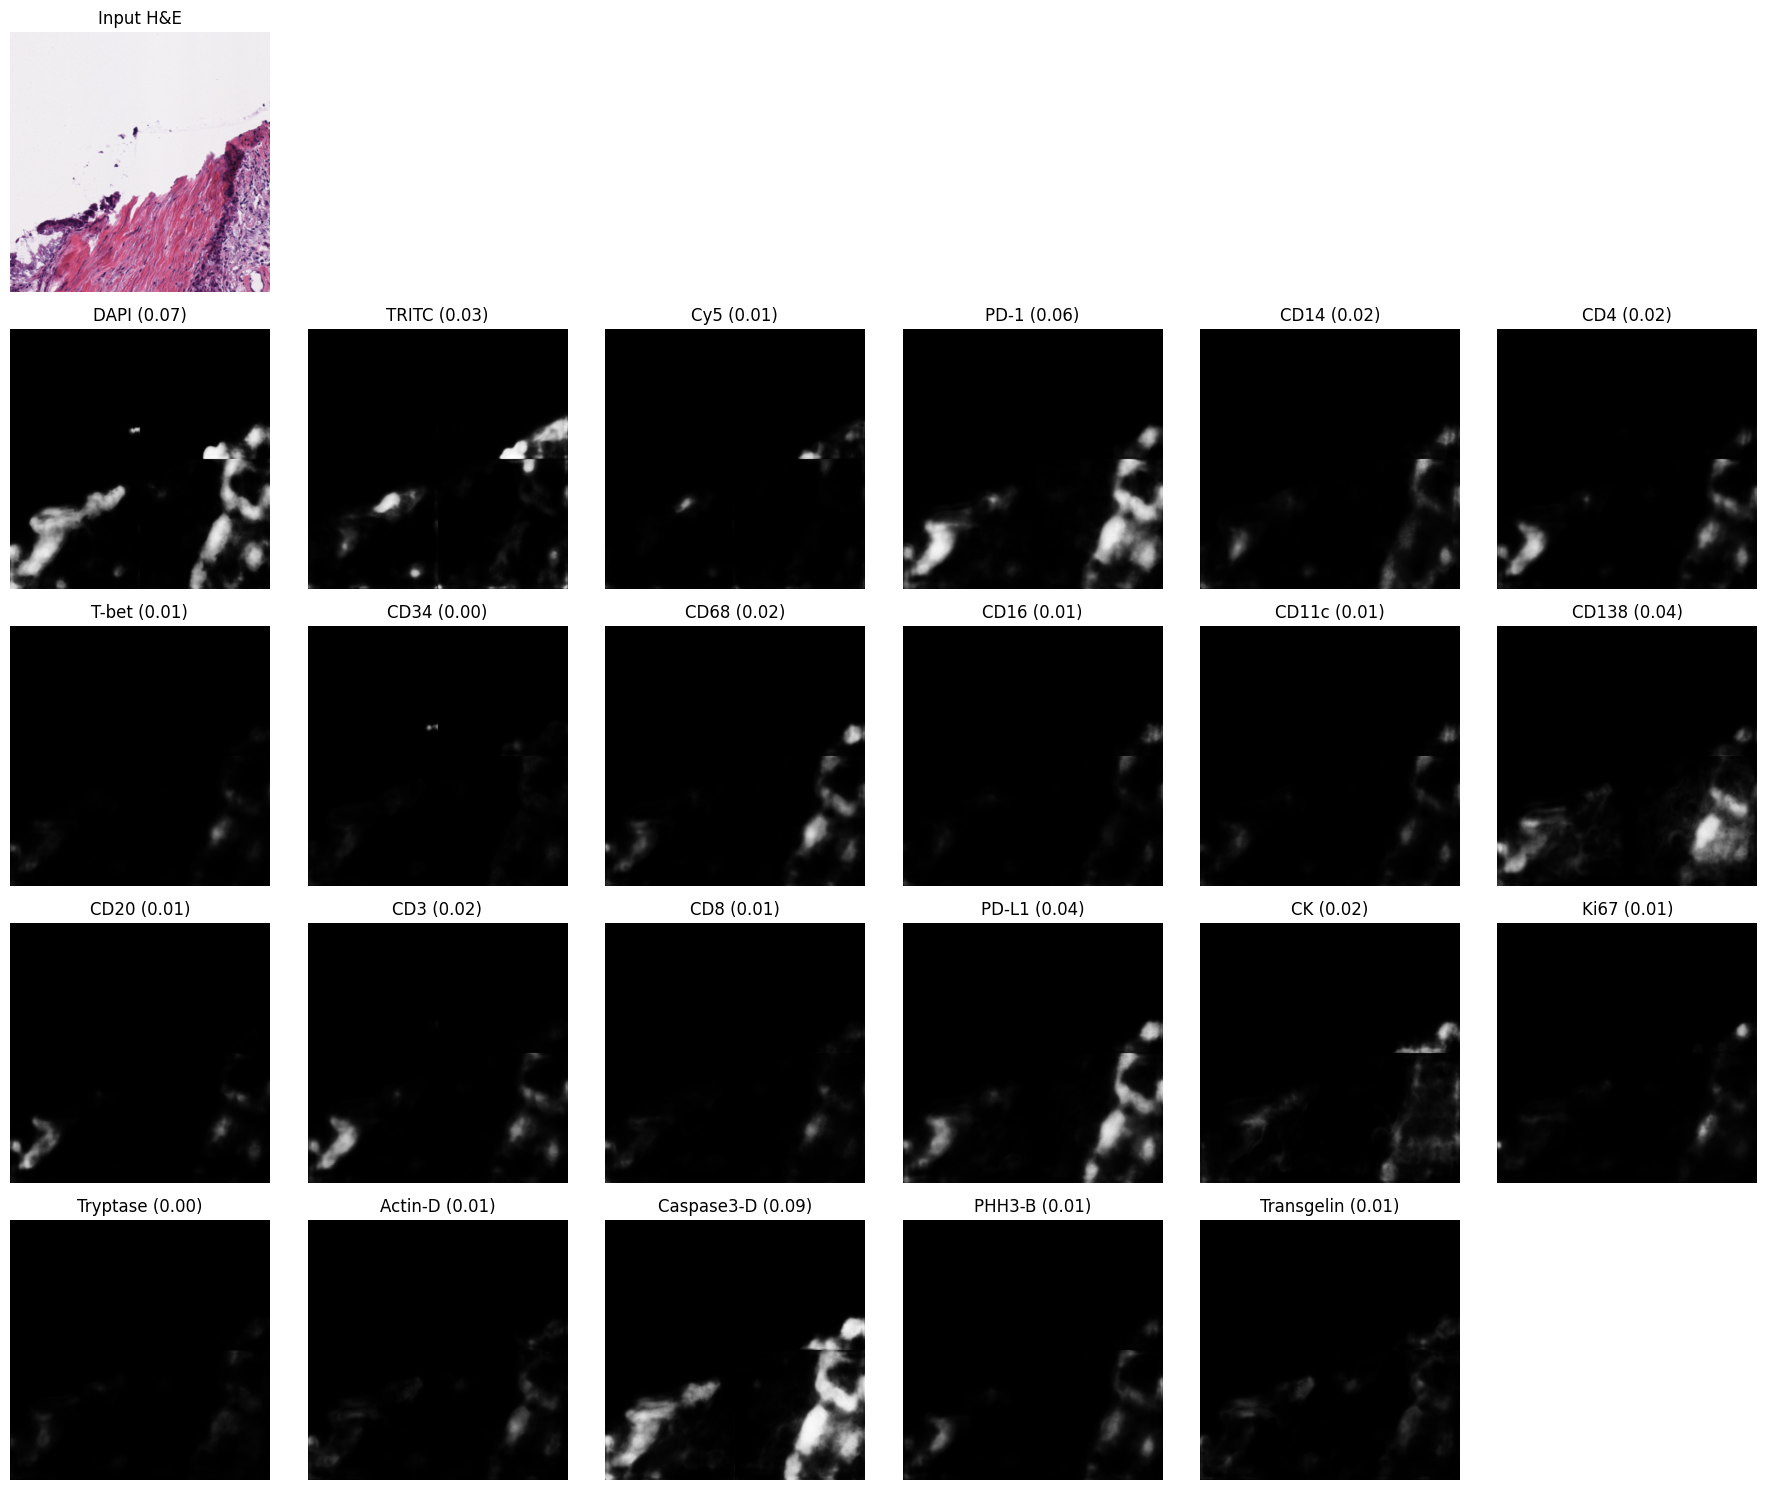

In [8]:
# Show GigaTIME predictions: HE tile + ALL predicted channels (for verification)
from prov_data import common_channel_list

# List all protein markers (IMF channels) for verification
print("All protein markers (common_channel_list):")
for i, name in enumerate(common_channel_list):
    print(f"  {i:2d}: {name}")
print()

if "probs" not in dir() or probs is None:
    print("Run the 'Run GigaTIME model' cell above first.")
else:
    idx = 0  # first sample in batch
    n_channels = probs.shape[1]
    # Denormalize HE for display (ImageNet mean/std used by transforms.Normalize())
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    he_img = batch_img[idx, :3].cpu().numpy().transpose(1, 2, 0)
    he_img = np.clip(he_img * std + mean, 0, 1)

    # Grid: row 0 = H&E, rows 1+ = all predicted channels (6 per row)
    n_cols = 6
    n_rows = 1 + (n_channels + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    axes = np.atleast_2d(axes)
    # H&E in top-left
    axes[0, 0].imshow(he_img)
    axes[0, 0].set_title("Input H&E")
    axes[0, 0].axis("off")
    for j in range(1, n_cols):
        axes[0, j].axis("off")
    # All predicted channels
    for ch in range(n_channels):
        r, c = 1 + ch // n_cols, ch % n_cols
        prob_map = probs[idx, ch].cpu().numpy()
        axes[r, c].imshow(prob_map, cmap="gray", vmin=0, vmax=1)
        name = common_channel_list[ch] if ch < len(common_channel_list) else f"ch{ch}"
        axes[r, c].set_title(f"{name} ({prob_map.mean():.2f})")
        axes[r, c].axis("off")
    # Hide unused subplots
    for ch in range(n_channels, (n_rows - 1) * n_cols):
        r, c = 1 + ch // n_cols, ch % n_cols
        axes[r, c].axis("off")
    plt.tight_layout()
    plt.show()

Raw outputs

Logits (pre-sigmoid), probabilities (post-sigmoid), and binary predictions from GigaTIME for the first batch. Per-channel summary and a small array slice.

In [9]:
# Raw model outputs (from the "Run GigaTIME model" cell)
from prov_data import common_channel_list

if "logits" not in dir() or logits is None:
    print("Run the 'Run GigaTIME model' cell first.")
else:
    idx = 0  # first sample
    print("Shapes:")
    print("  logits:", logits.shape)
    print("  probs (sigmoid):", probs.shape)
    print("  pred (binary >0.5):", pred.shape)
    print()
    print("First sample (idx=0) — per-channel stats:")
    print("  Channel          | logits min   max   mean  | probs min   max   mean")
    print("  " + "-" * 70)
    for ch in range(logits.shape[1]):
        name = common_channel_list[ch] if ch < len(common_channel_list) else f"ch{ch}"
        L = logits[idx, ch].cpu().numpy()
        P = probs[idx, ch].cpu().numpy()
        print(f"  {name:16s} | {L.min():7.2f} {L.max():6.2f} {L.mean():6.2f} | {P.min():.3f} {P.max():.3f} {P.mean():.3f}")
    print()
    print("Probability array slice (first channel, center 5x5):")
    center = probs[idx, 0].cpu().numpy()
    h, w = center.shape
    i, j = h // 2 - 2, w // 2 - 2
    print(center[i:i+5, j:j+5].round(4))
    print()
    print("Binary prediction counts (first sample, pixels with pred=1 per channel):")
    for ch in range(pred.shape[1]):
        name = common_channel_list[ch] if ch < len(common_channel_list) else f"ch{ch}"
        n = pred[idx, ch].sum().item()
        print(f"  {name}: {n:.0f}")

Shapes:
  logits: torch.Size([4, 23, 512, 512])
  probs (sigmoid): torch.Size([4, 23, 512, 512])
  pred (binary >0.5): torch.Size([4, 23, 512, 512])

First sample (idx=0) — per-channel stats:
  Channel          | logits min   max   mean  | probs min   max   mean
  ----------------------------------------------------------------------
  DAPI             |  -10.72   4.01  -6.05 | 0.000 0.982 0.073
  TRITC            |  -10.98   4.53  -6.43 | 0.000 0.989 0.029
  Cy5              |  -10.83   1.96  -7.30 | 0.000 0.877 0.006
  PD-1             |  -11.19   3.13  -6.22 | 0.000 0.958 0.063
  CD14             |  -11.04   1.09  -6.90 | 0.000 0.748 0.016
  CD4              |  -11.78   1.79  -7.21 | 0.000 0.858 0.021
  T-bet            |  -11.73  -0.02  -7.65 | 0.000 0.496 0.005
  CD34             |  -12.78   0.40  -7.30 | 0.000 0.598 0.004
  CD68             |  -12.98   1.81  -7.53 | 0.000 0.859 0.019
  CD16             |  -11.24  -0.19  -7.49 | 0.000 0.452 0.005
  CD11c            |  -11.70  -0.1